Training Samples: 16000
Testing Samples: 4000


C:\Users\Sadiya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 26)                  │             858 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4596 - loss: 2.0049 - val_accuracy: 0.6734 - val_loss: 1.2189
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7138 - loss: 0.9976 - val_accuracy: 0.7491 - val_loss: 0.9007
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7752 - loss: 0.7842 - val_accuracy: 0.7847 - val_loss: 0.7562
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8060 - loss: 0.6618 - val_accuracy: 0.8112 - val_loss: 0.6662
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8314 - loss: 0.5820 - val_accuracy: 0.8325 - val_loss: 0.5911
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8490 - loss: 0.5218 - val_accuracy: 0.8428 - val_loss: 0.5410
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.4721 - val_accuracy: 0.8494 - val_loss: 0.5044
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8717 - loss: 0.4344 - val_accuracy: 0.

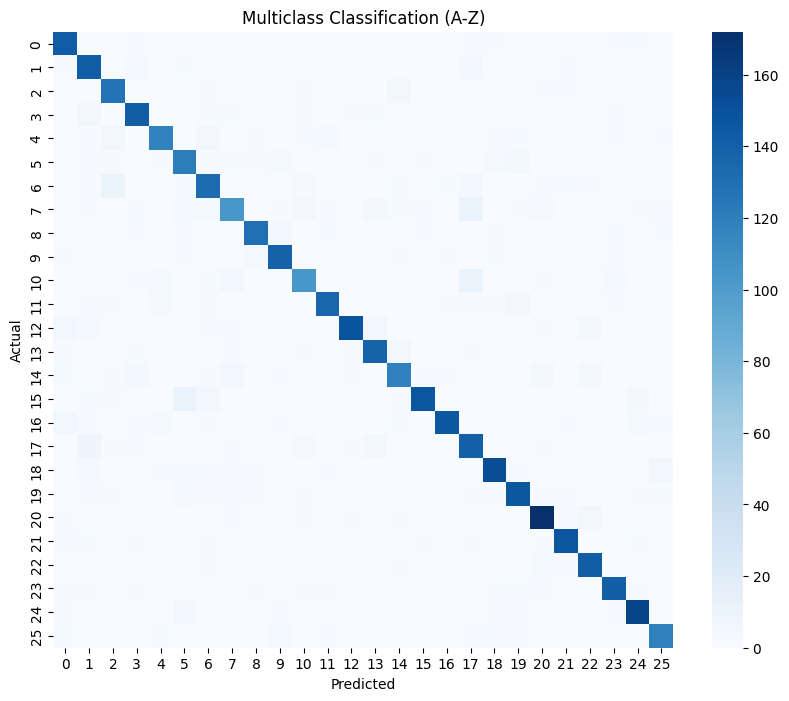

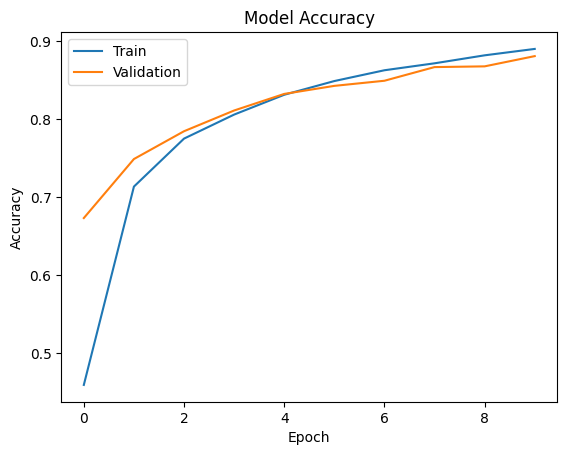

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

Actual Letter: T
Predicted Letter: Z


In [8]:
# Multiclass Classification using DNN
# UCI Letter Recognition Dataset

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load Dataset
data = pd.read_csv("letter-recognition.data", header=None)

# Input and Output
X = data.iloc[:,1:].values
y = data.iloc[:,0].values

# Encode Labels (A-Z → 0-25)
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# One Hot Encoding
y = to_categorical(y_encoded)

# Normalize Data
X = StandardScaler().fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Build DNN Model
model = Sequential([

    Dense(64, activation='relu', input_shape=(16,)),

    Dense(32, activation='relu'),

    Dense(26, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# Predict Classes
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# Accuracy Score
print("\nAccuracy Score:",
      accuracy_score(y_true, y_pred_classes))

# Show 26 Classes
print("\nMulticlass Labels (26 Classes):")

for letter in encoder.classes_:
    print(letter, end=" ")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap='Blues')

plt.title("Multiclass Classification (A-Z)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

# Single Prediction
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

predicted_letter = encoder.inverse_transform([predicted_class])

actual_class = np.argmax(y_test[0])

actual_letter = encoder.inverse_transform([actual_class])

print("\nActual Letter:", actual_letter[0])

print("Predicted Letter:", predicted_letter[0])
